# z-Verteilung (Standardnormalverteilung) – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/z-verteilung)

Die **Standardnormalverteilung** (z-Verteilung) ist eine Normalverteilung mit
Mittelwert μ = 0 und Standardabweichung σ = 1.

**Dichtefunktion:**
$$f(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}$$

**z-Standardisierung:**
$$z = \frac{x - \mu}{\sigma}$$

**p-Wert aus z-Wert:**

| Testtyp | p-Wert |
|---|---|
| **Linksseitig** | $P(Z \leq z) = \Phi(z)$ |
| **Rechtsseitig** | $P(Z \geq z) = 1 - \Phi(z)$ |
| **Zweiseitig** | $P(|Z| \geq |z|) = 2 \cdot (1 - \Phi(|z|))$ |

**Wichtige kritische z-Werte:**

| Signifikanzniveau α | Zweiseitig | Einseitig |
|---|---|---|
| 0,05 | ±1,96 | ±1,645 |
| 0,01 | ±2,576 | ±2,326 |
| 0,001 | ±3,291 | ±3,090 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Die Standardnormalverteilung

Die Fläche unter der Kurve zwischen zwei z-Werten entspricht der Wahrscheinlichkeit,
dass Z in diesem Bereich liegt. Die Gesamtfläche = 1.

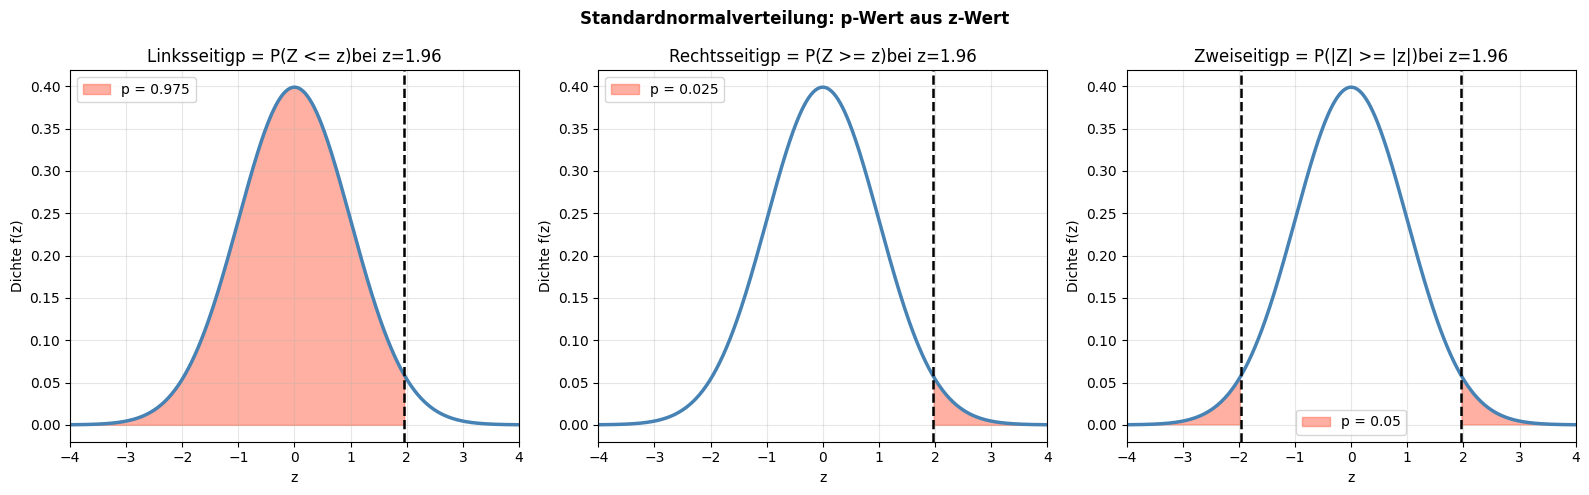

In [2]:
z = np.linspace(-4, 4, 400)
pdf = norm.pdf(z)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Standardnormalverteilung: p-Wert aus z-Wert", fontsize=12,
             fontweight="bold")

z_bsp = 1.96

for ax, titel, fill_cond, pval_label in [
    (axes[0], "Linksseitigp = P(Z <= z)",
     z <= z_bsp,
     "p = " + str(round(norm.cdf(z_bsp), 4))),
    (axes[1], "Rechtsseitigp = P(Z >= z)",
     z >= z_bsp,
     "p = " + str(round(1 - norm.cdf(z_bsp), 4))),
    (axes[2], "Zweiseitigp = P(|Z| >= |z|)",
     (z <= -z_bsp) | (z >= z_bsp),
     "p = " + str(round(2 * (1 - norm.cdf(z_bsp)), 4))),
]:
    ax.plot(z, pdf, color="steelblue", linewidth=2.5)
    ax.fill_between(z, pdf, where=fill_cond, color="tomato", alpha=0.5, label=pval_label)
    ax.axvline(z_bsp, color="black", linestyle="--", linewidth=1.8)
    if titel.startswith("Zweiseitig"):
        ax.axvline(-z_bsp, color="black", linestyle="--", linewidth=1.8)
    ax.set_title(titel + "bei z=" + str(z_bsp))
    ax.set_xlabel("z")
    ax.set_ylabel("Dichte f(z)")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(-4, 4)

plt.tight_layout()
plt.show()

## 2. p-Wert aus z-Wert berechnen

`scipy.stats.norm.cdf(z)` gibt Φ(z) zurück – die kumulierte Wahrscheinlichkeit
links von z.

In [7]:
def p_aus_z(z_val, test="zweiseitig"):
    if test == "linksseitig":
        return norm.cdf(z_val)
    elif test == "rechtsseitig":
        return 1 - norm.cdf(z_val)
    else:  # zweiseitig
        return 2 * (1 - norm.cdf(abs(z_val)))

print("p-Wert aus z-Wert")
print()
print("z-Wert   linksseitig  rechtsseitig  zweiseitig")
print()
for z_val in [-3.0, -2.576, -1.96, -1.645, 0.0,
               1.645, 1.96, 2.576, 3.0]:
    pl = p_aus_z(z_val, "linksseitig")
    pr = p_aus_z(z_val, "rechtsseitig")
    pz = p_aus_z(z_val, "zweiseitig")
    sig = " <- p<0.05" if pz < 0.05 else ""
    print(str(round(z_val, 3)).rjust(6) + "   " +
          str(round(pl, 4)).ljust(12) + "  " +
          str(round(pr, 4)).ljust(12) + "  " +
          str(round(pz, 4)) + sig)

print()
print("Kritische z-Werte für alpha=0.05:")
print("  Zweiseitig: z_krit = +/-" + str(round(norm.ppf(0.975), 4)))
print("  Einseitig:  z_krit = +/-" + str(round(norm.ppf(0.95), 4)))

p-Wert aus z-Wert

z-Wert   linksseitig  rechtsseitig  zweiseitig

  -3.0   0.0013        0.9987        0.0027 <- p<0.05
-2.576   0.005         0.995         0.01 <- p<0.05
 -1.96   0.025         0.975         0.05 <- p<0.05
-1.645   0.05          0.95          0.1
   0.0   0.5           0.5           1.0
 1.645   0.95          0.05          0.1
  1.96   0.975         0.025         0.05 <- p<0.05
 2.576   0.995         0.005         0.01 <- p<0.05
   3.0   0.9987        0.0013        0.0027 <- p<0.05

Kritische z-Werte für alpha=0.05:
  Zweiseitig: z_krit = +/-1.96
  Einseitig:  z_krit = +/-1.6449


## 3. z-Tabelle (Standardnormalverteilung)

Die Tabelle zeigt **Φ(z) = P(Z ≤ z)** – die Fläche links von z.
Zum Ablesen: Zeile = ganze + erste Dezimalstelle, Spalte = zweite Dezimalstelle.

In [4]:
# z-Tabelle für negative z-Werte (wie auf numiqo.de)
zeilen_z = np.arange(-3.4, 0.1, 0.1).round(1)
spalten_d = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

tabelle = {}
for z_row in zeilen_z:
    row_vals = {}
    for d in spalten_d:
        z_val = round(z_row + d, 2) if z_row < 0 else round(z_row - d, 2)
        row_vals[str(d)] = round(norm.cdf(z_val), 4)
    tabelle[str(round(z_row, 1))] = row_vals

df_tab = pd.DataFrame(tabelle).T
df_tab.columns = [str(d) for d in spalten_d]
df_tab.index.name = "z"

print("Standardnormalverteilung Tabelle (negative z-Werte)")
print("Werte entsprechen Phi(z) = P(Z <= z)")
print()
print(df_tab.to_string())
print()
print("Beispiel: z = -1.96 -> Phi(-1.96) = " +
      str(round(norm.cdf(-1.96), 4)))
print("          -> p (zweiseitig) = 2 * 0.0250 = 0.0500")

Standardnormalverteilung Tabelle (negative z-Werte)
Werte entsprechen Phi(z) = P(Z <= z)

         0.0    0.01    0.02    0.03    0.04    0.05    0.06    0.07    0.08    0.09
z                                                                                   
-3.4  0.0003  0.0003  0.0004  0.0004  0.0004  0.0004  0.0004  0.0004  0.0005  0.0005
-3.3  0.0005  0.0005  0.0005  0.0005  0.0006  0.0006  0.0006  0.0006  0.0006  0.0007
-3.2  0.0007  0.0007  0.0007  0.0008  0.0008  0.0008  0.0008  0.0009  0.0009  0.0009
-3.1  0.0010  0.0010  0.0010  0.0011  0.0011  0.0011  0.0012  0.0012  0.0013  0.0013
-3.0  0.0013  0.0014  0.0014  0.0015  0.0015  0.0016  0.0016  0.0017  0.0018  0.0018
-2.9  0.0019  0.0019  0.0020  0.0021  0.0021  0.0022  0.0023  0.0023  0.0024  0.0025
-2.8  0.0026  0.0026  0.0027  0.0028  0.0029  0.0030  0.0031  0.0032  0.0033  0.0034
-2.7  0.0035  0.0036  0.0037  0.0038  0.0039  0.0040  0.0041  0.0043  0.0044  0.0045
-2.6  0.0047  0.0048  0.0049  0.0051  0.0052  0.0054  0.0055

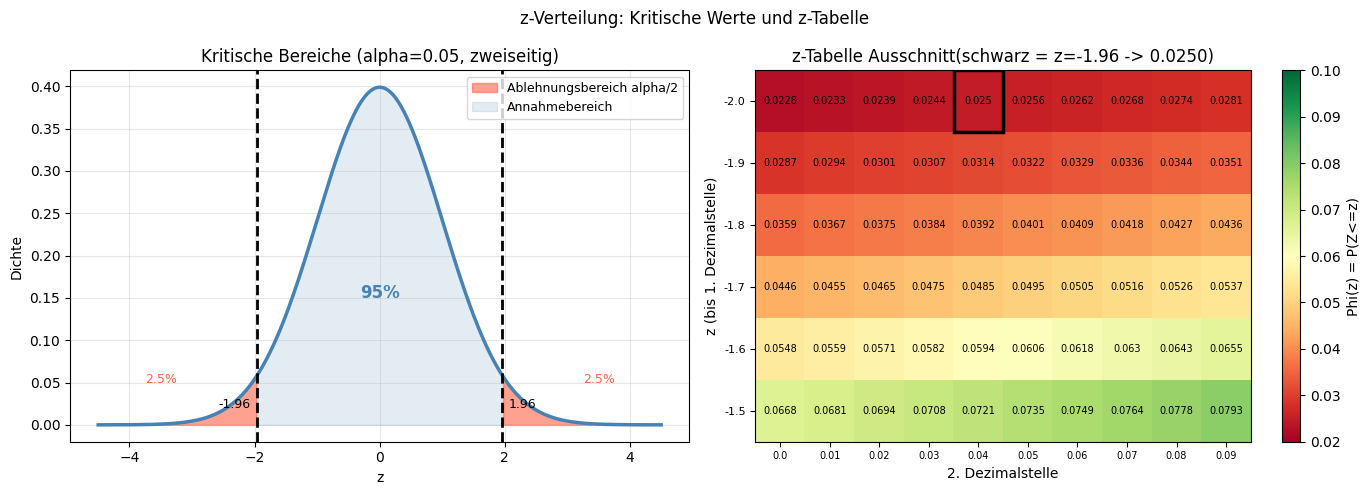

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("z-Verteilung: Kritische Werte und z-Tabelle", fontsize=12)

z = np.linspace(-4.5, 4.5, 500)
pdf = norm.pdf(z)

# 1. Kritische Bereiche alpha=0.05 zweiseitig
z_krit = norm.ppf(0.975)
axes[0].plot(z, pdf, color="steelblue", linewidth=2.5)
axes[0].fill_between(z, pdf, where=(z <= -z_krit), color="tomato",
                     alpha=0.6, label="Ablehnungsbereich alpha/2")
axes[0].fill_between(z, pdf, where=(z >= z_krit), color="tomato", alpha=0.6)
axes[0].fill_between(z, pdf, where=(z > -z_krit) & (z < z_krit),
                     color="steelblue", alpha=0.15, label="Annahmebereich")
axes[0].axvline(-z_krit, color="black", linestyle="--", linewidth=2)
axes[0].axvline(z_krit,  color="black", linestyle="--", linewidth=2)
axes[0].text(-z_krit - 0.1, 0.02, "-1.96", ha="right", fontsize=9)
axes[0].text( z_krit + 0.1, 0.02,  "1.96", ha="left",  fontsize=9)
axes[0].text(0, 0.15, "95%", ha="center", fontsize=12, color="steelblue",
             fontweight="bold")
axes[0].text(-3.5, 0.05, "2.5%", ha="center", fontsize=9, color="tomato")
axes[0].text( 3.5, 0.05, "2.5%", ha="center", fontsize=9, color="tomato")
axes[0].set_title("Kritische Bereiche (alpha=0.05, zweiseitig)")
axes[0].set_xlabel("z")
axes[0].set_ylabel("Dichte")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# 2. Farbkodierte z-Tabelle (Heatmap Ausschnitt)
zeilen_vis = [-2.0, -1.9, -1.8, -1.7, -1.6, -1.5]
spalten_vis = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]
mat = np.array([[norm.cdf(z_r + s) for s in spalten_vis] for z_r in zeilen_vis])
im = axes[1].imshow(mat, cmap="RdYlGn", vmin=0.02, vmax=0.10, aspect="auto")
plt.colorbar(im, ax=axes[1], label="Phi(z) = P(Z<=z)")
axes[1].set_xticks(range(len(spalten_vis)))
axes[1].set_yticks(range(len(zeilen_vis)))
axes[1].set_xticklabels([str(s) for s in spalten_vis], fontsize=7)
axes[1].set_yticklabels([str(z_r) for z_r in zeilen_vis], fontsize=8)
for i in range(len(zeilen_vis)):
    for j in range(len(spalten_vis)):
        axes[1].text(j, i, str(round(mat[i,j], 4)),
                     ha="center", va="center", fontsize=7)
# Markiere z=-1.96
row_idx = zeilen_vis.index(-2.0)
col_idx = spalten_vis.index(0.04)
axes[1].add_patch(plt.Rectangle((col_idx-0.5, row_idx-0.5), 1, 1,
                                 fill=False, edgecolor="black", linewidth=2.5))
axes[1].set_title("z-Tabelle Ausschnitt(schwarz = z=-1.96 -> 0.0250)")
axes[1].set_xlabel("2. Dezimalstelle")
axes[1].set_ylabel("z (bis 1. Dezimalstelle)")

plt.tight_layout()
plt.show()

## 4. z-Standardisierung und p-Wert Beispiel

**Praxisbeispiel:** Eine Produktion hat μ=500g, σ=20g.
Ein Stück wiegt x=545g. Wie wahrscheinlich ist ein so extremer Wert?

Praxisbeispiel: z-Standardisierung
x=545g, mu=500g, sigma=20g

z = (x - mu) / sigma = (545 - 500) / 20 = 2.25

p (zweiseitig) = 2 * (1 - Phi(2.25))
               = 2 * (1 - 0.9878)
               = 0.0244

-> p < 0.05: Signifikant! x=545g ist extrem selten (weniger als 5% Wahrscheinlichkeit).


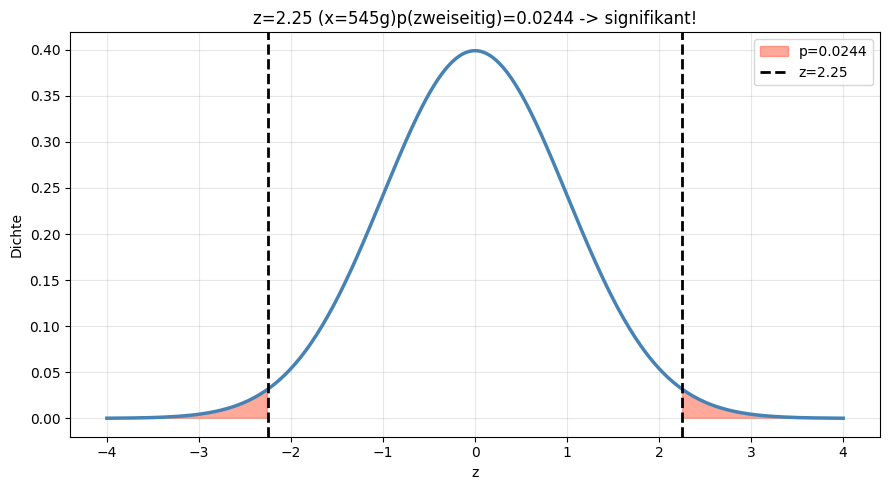

In [6]:
# Praxisbeispiel: z-Standardisierung
mu = 500
sigma = 20
x = 545

z_val = (x - mu) / sigma
p_zs = 2 * (1 - norm.cdf(abs(z_val)))

print("Praxisbeispiel: z-Standardisierung")
print("x=" + str(x) + "g, mu=" + str(mu) + "g, sigma=" + str(sigma) + "g")
print()
print("z = (x - mu) / sigma = (" + str(x) + " - " + str(mu) +
      ") / " + str(sigma) + " = " + str(round(z_val, 4)))
print()
print("p (zweiseitig) = 2 * (1 - Phi(" + str(round(z_val,4)) + "))")
print("               = 2 * (1 - " + str(round(norm.cdf(z_val),4)) + ")")
print("               = " + str(round(p_zs, 4)))
print()
if p_zs < 0.05:
    print("-> p < 0.05: Signifikant! x=" + str(x) +
          "g ist extrem selten (weniger als 5% Wahrscheinlichkeit).")
else:
    print("-> p >= 0.05: Nicht signifikant.")

# Visualisierung
fig, ax = plt.subplots(figsize=(9, 5))
z_plot = np.linspace(-4, 4, 400)
ax.plot(z_plot, norm.pdf(z_plot), color="steelblue", linewidth=2.5)
ax.fill_between(z_plot, norm.pdf(z_plot),
                where=(z_plot >= z_val) | (z_plot <= -z_val),
                color="tomato", alpha=0.55,
                label="p=" + str(round(p_zs, 4)))
ax.axvline(z_val, color="black", linestyle="--", linewidth=2,
           label="z=" + str(round(z_val, 2)))
ax.axvline(-z_val, color="black", linestyle="--", linewidth=2)
ax.set_title("z=" + str(round(z_val,2)) + " (x=" + str(x) + "g)" +
             "p(zweiseitig)=" + str(round(p_zs,4)) +
             (" -> signifikant!" if p_zs < 0.05 else ""))
ax.set_xlabel("z")
ax.set_ylabel("Dichte")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Zusammenfassung

```
z-Verteilung (Standardnormalverteilung) – Übersicht
│
├── DEFINITION
│   Normalverteilung mit mu=0, sigma=1
│   f(z) = (1/sqrt(2*pi)) * e^(-z^2/2)
│
├── z-STANDARDISIERUNG
│   z = (x - mu) / sigma
│   Macht Werte aus verschiedenen Skalen vergleichbar
│
├── p-WERT AUS z-WERT
│   Linksseitig:  p = Phi(z)         = norm.cdf(z)
│   Rechtsseitig: p = 1 - Phi(z)     = 1 - norm.cdf(z)
│   Zweiseitig:   p = 2*(1 - Phi(|z|)) = 2*(1-norm.cdf(abs(z)))
│
├── KRITISCHE z-WERTE
│   alpha=0.05 zweiseitig: z_krit = +/-1.96
│   alpha=0.05 einseitig:  z_krit = +/-1.645
│   alpha=0.01 zweiseitig: z_krit = +/-2.576
│
├── z-TABELLE LESEN
│   Zeile: z bis 1. Dezimalstelle (z.B. -1.9)
│   Spalte: 2. Dezimalstelle (z.B. 0.06)
│   Zellwert: Phi(z) = P(Z <= z)
│   Beispiel: z=-1.96 -> Phi(-1.96)=0.0250
│
└── PYTHON
    from scipy.stats import norm
    phi_z  = norm.cdf(z)        # Phi(z)
    p_link = norm.cdf(z)
    p_rech = 1 - norm.cdf(z)
    p_zwei = 2 * (1 - norm.cdf(abs(z)))
    z_krit = norm.ppf(0.975)    # kritischer z-Wert alpha=0.05
```

---
Quelle: [numiqo.de/tutorial/z-verteilung](https://numiqo.de/tutorial/z-verteilung)